# Sales Data Analysis

A Python analysis of retail sales data (Python equivalent of the original Power BI project),
built on top of a reusable `src/` package for data loading, cleaning, feature engineering,
analysis and visualization.

**Data source:** `data/store_data.xlsx` — 4 sheets: `Sheet3` (sales fact table),
`Dim Customers`, `Dim Product`, `Dim Promotion`.

## Business Questions Answered

| # | Question |
|---|----------|
| Q1 | Top / Bottom 5 products by Sales, Profit and Quantity Sold |
| Q2 | How do sales trends vary over time (daily, monthly, quarterly, yearly)? |
| Q3 | What is the relationship between Sales and Profit? |
| Q4 | Compare Sales / Profit / Quantity Sold between any two user-selected periods |
| Q5 | Average discount offered in each discount category |
| Q6 | Total number of orders |
| Q7 | Sales / Profit / Discount / Net Sales / all fields for each order, filterable by Product / Date / Customer ID / Promotion |
| Q8 | Sales by different cities |


## Setup

In [1]:
import sys
sys.path.append("..")

from src.data_loader import load_data
from src.data_cleaning import clean_customers, clean_fact
from src.feature_engineering import compute_derived_columns, build_master_table
from src import analysis, visualization

import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## Load & Clean Data

Raw data is loaded via `src.data_loader.load_data`, then cleaned via `src.data_cleaning`.


In [2]:
raw = load_data("../data/store_data.xlsx")

fact = clean_fact(raw["fact"])
customers = clean_customers(raw["customers"])
products = raw["products"]
promotions = raw["promotions"]

fact.shape, customers.shape, products.shape, promotions.shape


((3510, 10), (50, 7), (30, 4), (5, 5))

## Fill Any Missing Derived Columns & Build Master Table

The current workbook already ships `PricePerUnit`, `TotalSales`, `DiscountPct` (Discount Percentage), `DiscountValue` (Discount) and `NetSales` populated in the fact table, plus a `Profit` column that earlier versions did not have. `src.feature_engineering.compute_derived_columns` only recomputes a value where it is missing (`NaN`), so this cell works unchanged whether the workbook has these fields filled in or blank. Key assumptions used for any value that still needs computing (see module docstring for full detail):

- `DiscountPct` prefers `Dim Promotion["Percentage"]` when present, falling back to parsing `Dim Promotion["Price Reduction Type"]` (e.g. `"20% off"` -> 0.20). `"Buy 1 Get 1 Free"` is treated as an effective 50% discount.
- `Profit` falls back to a flat **10% margin on Net Sales** when not supplied directly (no Cost column exists in the source data) - replace with real cost data if available.


In [3]:
fact = compute_derived_columns(fact, products, promotions)
master = build_master_table(fact, products, customers, promotions)
master.head()


,Date,CustomerID,PromotionID,ProductID,UnitsSold,PricePerUnit,TotalSales,DiscountPct,DiscountValue,NetSales,...,Customer Name,City,State,Pincode,EmailID,Phone Number,Promotion Name,Ad Type,Coupon Code,Price Reduction Type
0,2020-02-04,10,NaN,P004,2,64999,129998,0.00,0.00,"129,998.00",...,Dhruv Desai,Pune,Maharashtra,411001,10Dhruv@gmail.com,900051106,No Promotion,NaN,NaN,NaN
1,2022-05-19,28,PR001,P027,3,699,2097,0.20,419.40,"1,677.60",...,Nikhil Khanna,Indore,Madhya Pradesh,452001,28Nikhil@gmail.com,930431648,Summer Sale,Email,SUMMER21,20% off
2,2022-07-01,2,NaN,P011,3,1499,4497,0.00,0.00,"4,497.00",...,Aditi Patel,Bhopal,Madhya Pradesh,462001,2Aditi@gmail.com,896750475,No Promotion,NaN,NaN,NaN
3,2022-04-06,11,PR001,P009,2,3499,6998,0.20,"1,399.60","5,598.40",...,Diya Kapoor,Mumbai,Maharashtra,400001,11Diya@gmail.com,845767347,Summer Sale,Email,SUMMER21,20% off
4,2022-01-02,34,NaN,P002,1,69999,69999,0.00,0.00,"69,999.00",...,Rajeev Trivedi,Hyderabad,Telangana,500001,34Rajeev@gmail.com,944295777,No Promotion,NaN,NaN,NaN


## Q1 — Top / Bottom 5 Products by Sales, Profit and Quantity Sold

/home/claude/project/notebooks/../src/visualization.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n.values, y=top_n.index, ax=axes[0], palette="crest")
/home/claude/project/notebooks/../src/visualization.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_n.values, y=bottom_n.index, ax=axes[1], palette="flare")


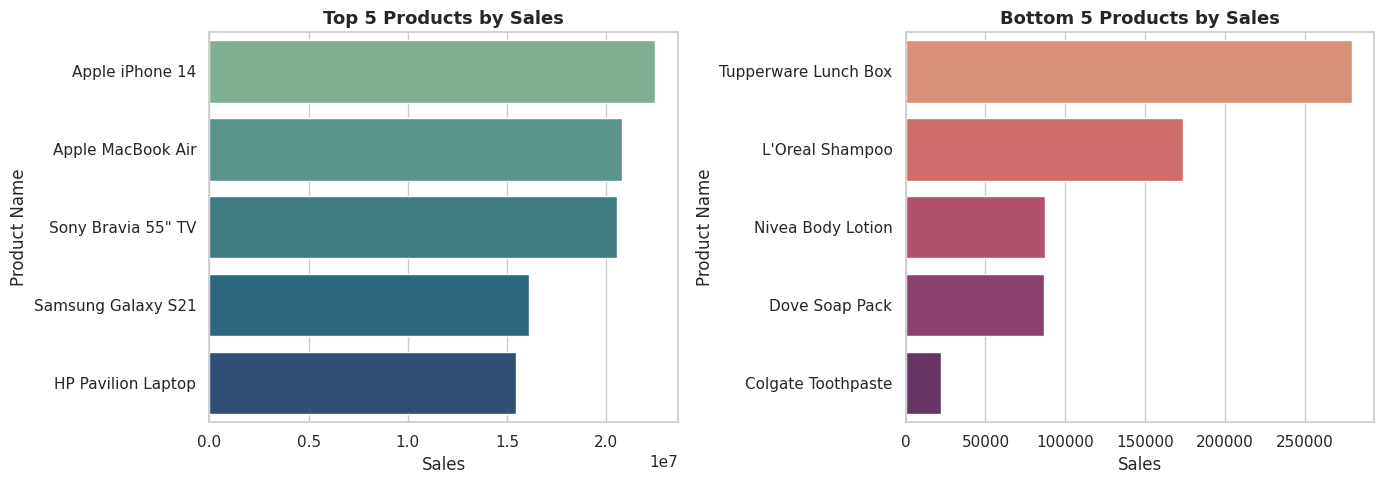

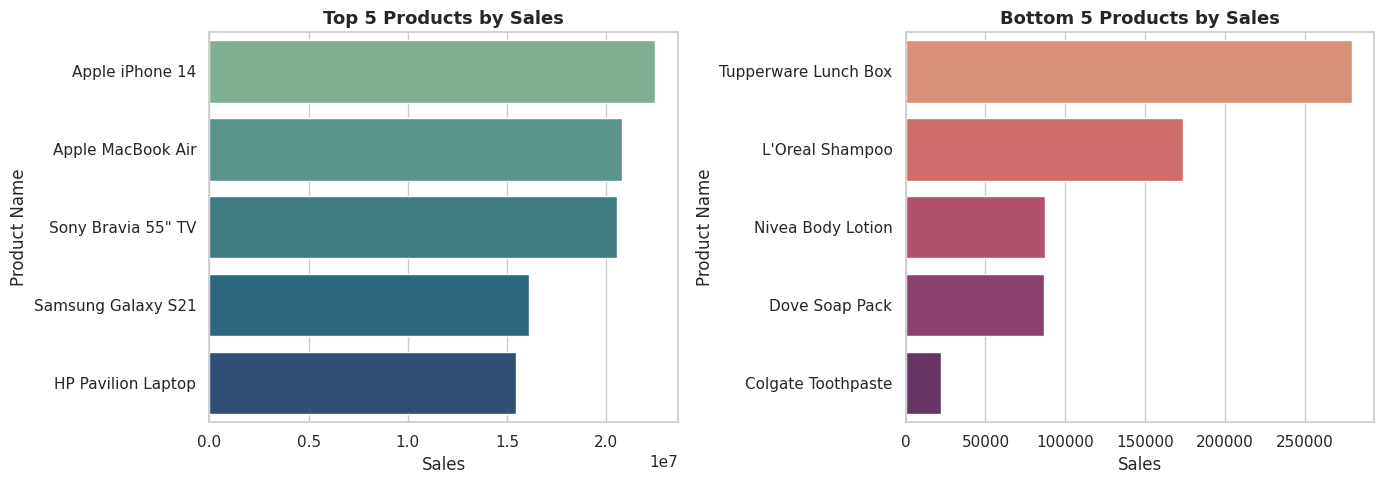

In [4]:
top_sales, bottom_sales = analysis.top_bottom_products(master, "TotalSales")
visualization.plot_top_bottom(top_sales, bottom_sales, "Sales", "01_top_bottom_sales.png")


/home/claude/project/notebooks/../src/visualization.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n.values, y=top_n.index, ax=axes[0], palette="crest")
/home/claude/project/notebooks/../src/visualization.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_n.values, y=bottom_n.index, ax=axes[1], palette="flare")


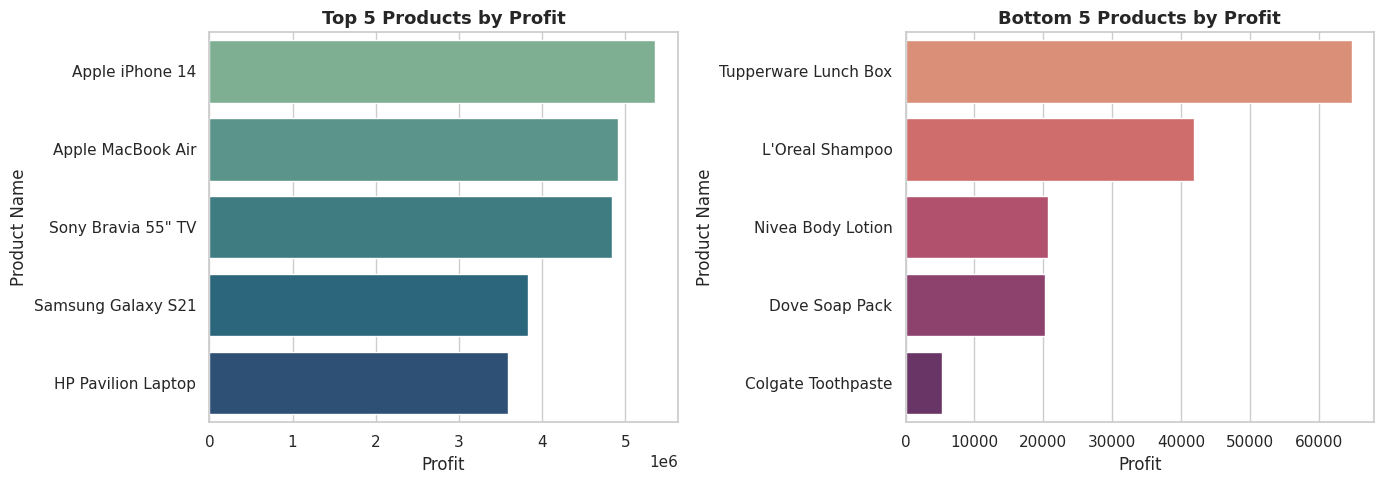

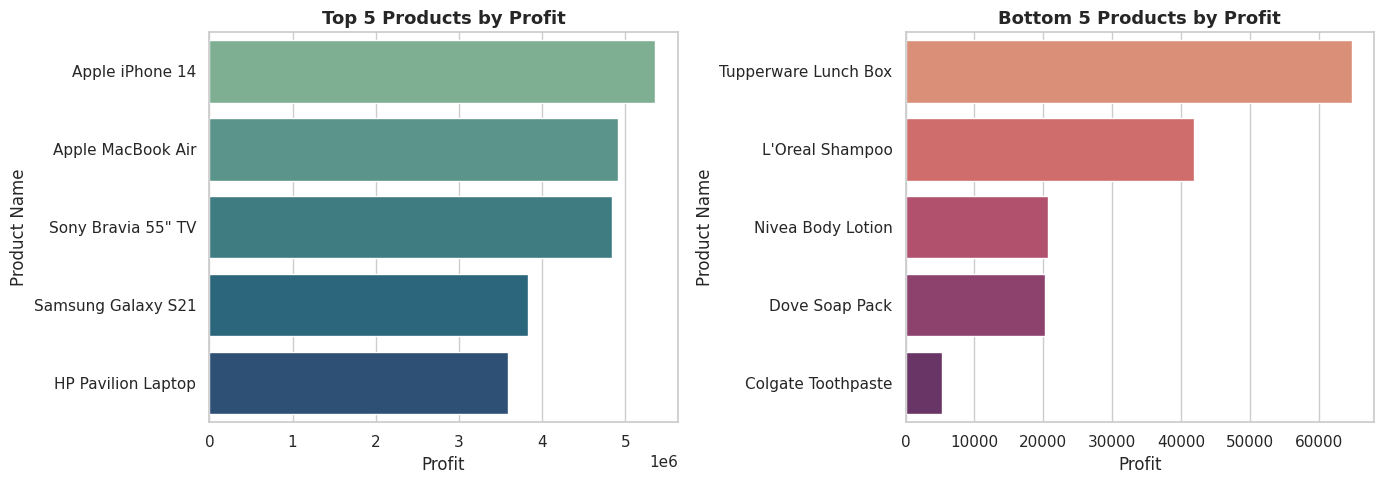

In [5]:
top_profit, bottom_profit = analysis.top_bottom_products(master, "Profit")
visualization.plot_top_bottom(top_profit, bottom_profit, "Profit", "01_top_bottom_profit.png")


/home/claude/project/notebooks/../src/visualization.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n.values, y=top_n.index, ax=axes[0], palette="crest")
/home/claude/project/notebooks/../src/visualization.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_n.values, y=bottom_n.index, ax=axes[1], palette="flare")


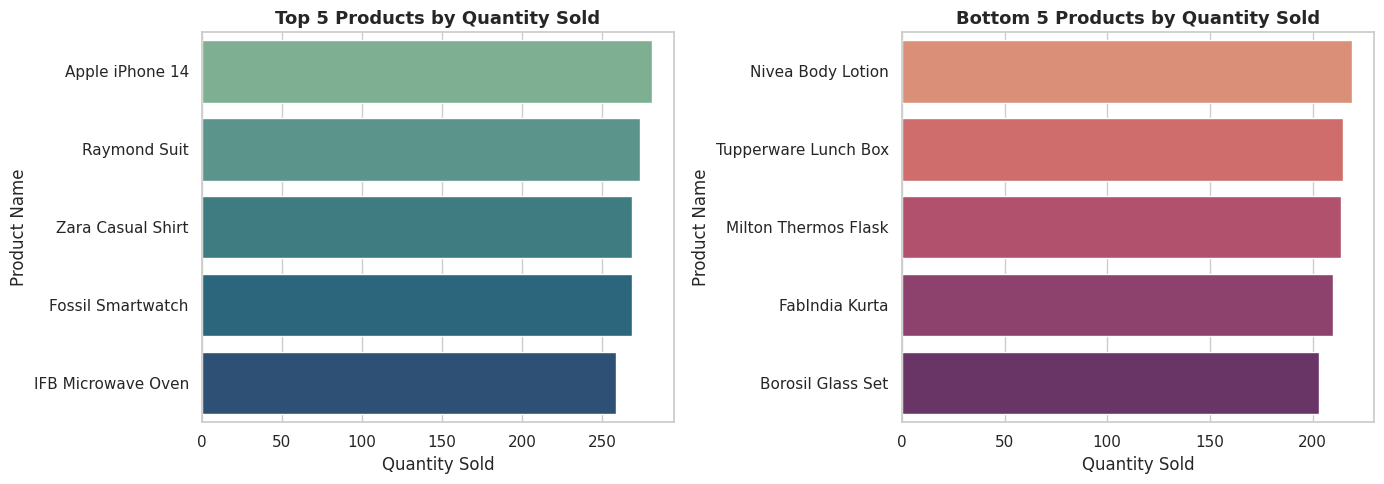

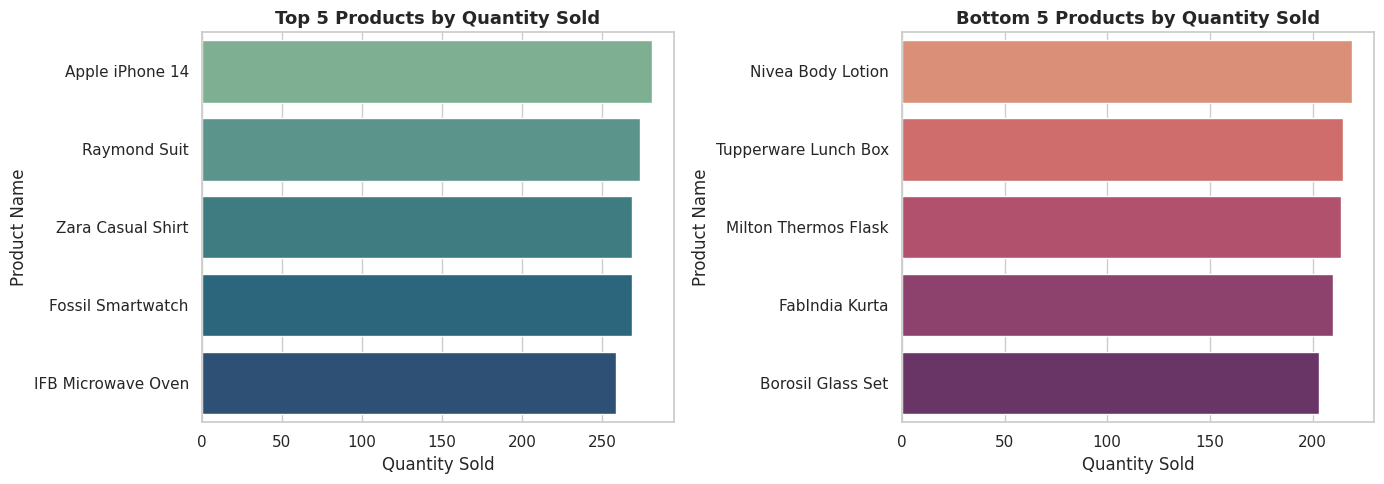

In [6]:
top_qty, bottom_qty = analysis.top_bottom_products(master, "UnitsSold")
visualization.plot_top_bottom(top_qty, bottom_qty, "Quantity Sold", "01_top_bottom_quantity.png")


## Q2 — Sales Trends Over Time (Daily, Monthly, Quarterly, Yearly)

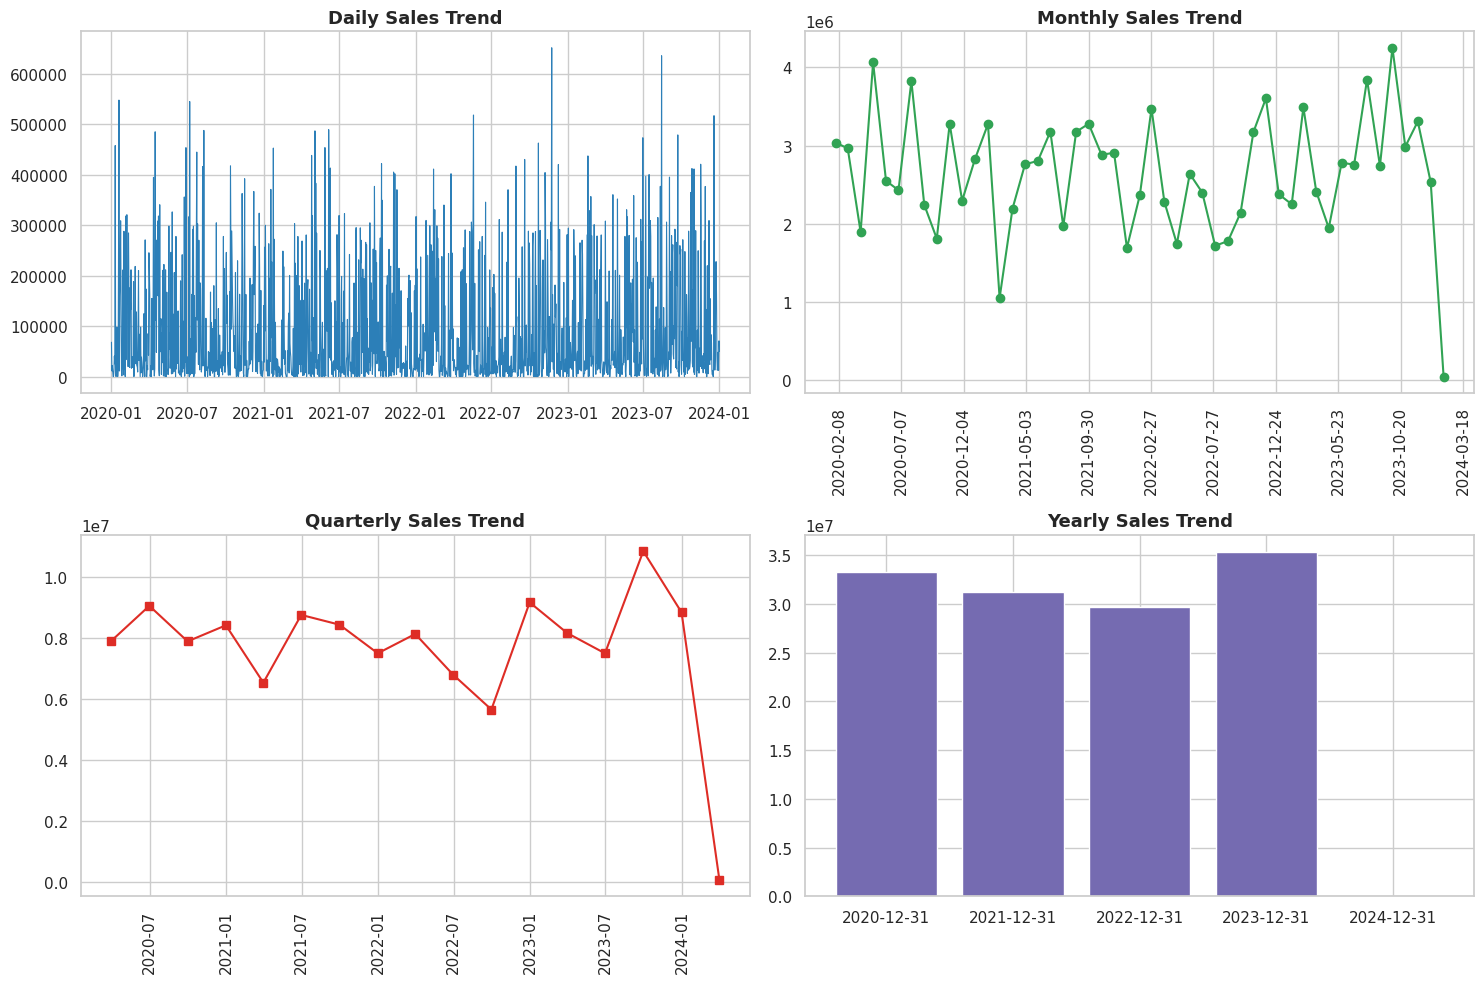

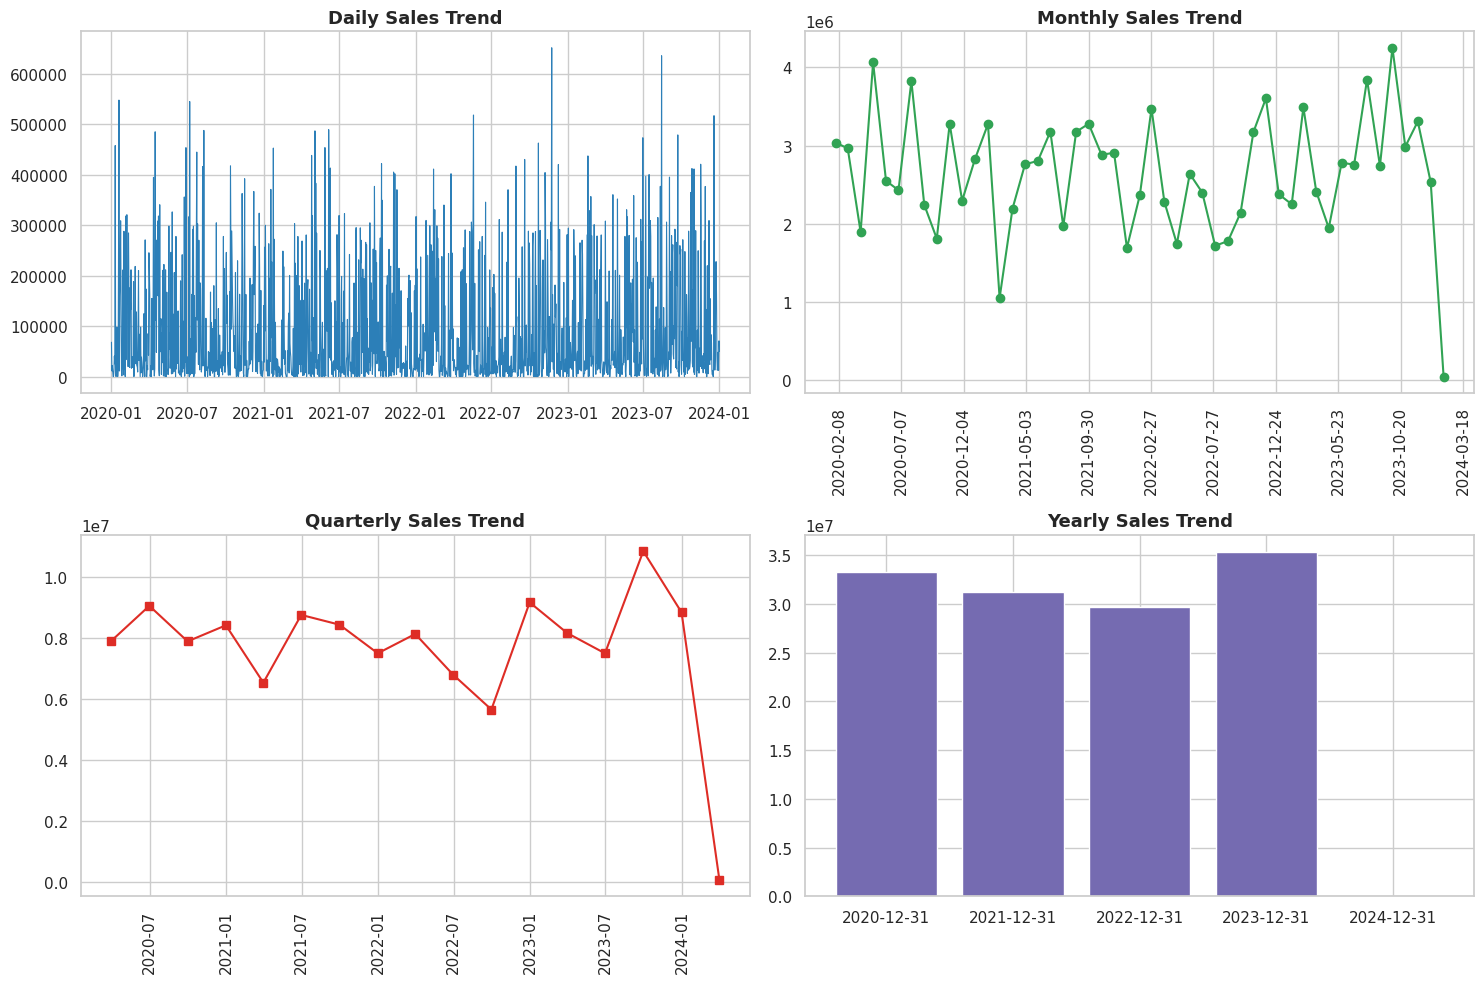

In [7]:
daily = analysis.sales_trend(master, freq="D")
monthly = analysis.sales_trend(master, freq="ME")
quarterly = analysis.sales_trend(master, freq="QE")
yearly = analysis.sales_trend(master, freq="YE")

visualization.plot_sales_trends(daily, monthly, quarterly, yearly)


## Q3 — Relationship Between Sales and Profit

Pearson correlation (Sales vs Profit): 0.988


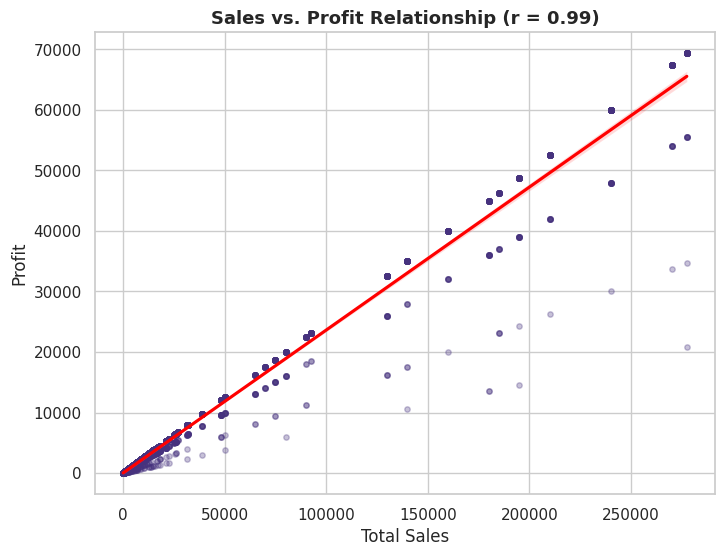

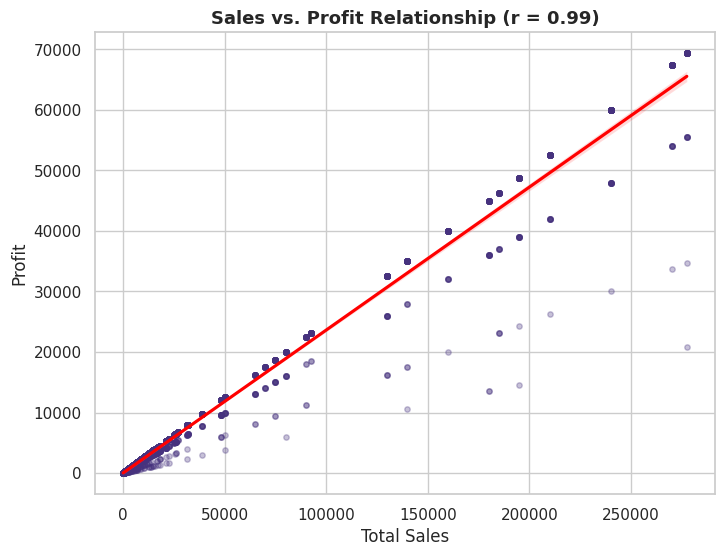

In [8]:
corr = analysis.sales_profit_correlation(master)
print(f"Pearson correlation (Sales vs Profit): {corr:.3f}")

visualization.plot_sales_profit_relationship(master, corr)


## Q4 — Compare Sales / Profit / Quantity Between Two Periods

`analysis.compare_periods` accepts any two `(start, end)` date ranges — swap in whatever
periods you want to compare.


,H1 2022,H2 2022,Change %
Total Sales,"14,909,208.00","14,802,751.00",-0.70
Total Profit,"3,506,403.40","3,653,935.85",4.20
Total Quantity,892.00,849.00,-4.80
Orders,439.00,415.00,-5.50


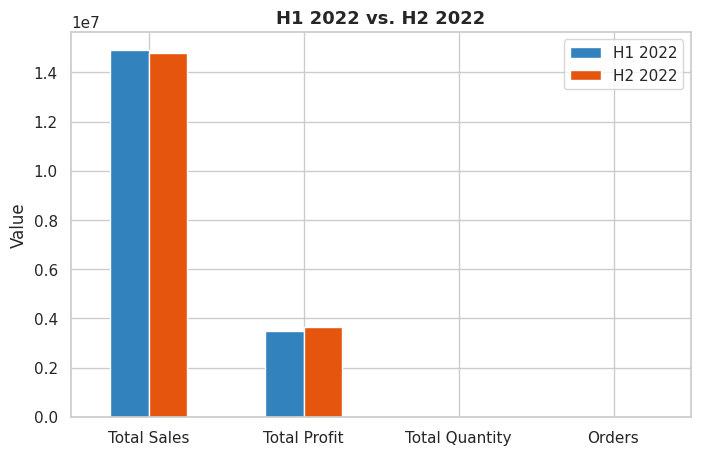

In [9]:
labels = ("H1 2022", "H2 2022")
comparison = analysis.compare_periods(
    master,
    period1=("2022-01-01", "2022-06-30"),
    period2=("2022-07-01", "2022-12-31"),
    labels=labels,
)
visualization.plot_period_comparison(comparison, labels)
comparison


## Q5 — Average Discount Offered in Each Discount Category

/home/claude/project/notebooks/../src/visualization.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_discount.values, y=avg_discount.index, palette="mako", ax=ax)


Promotion Name
Clearance Sale       70.00
New Year Special     50.00
Weekend Flash Sale   50.00
Summer Sale          20.00
Festive Diwali       10.00
No Promotion          0.00
Name: DiscountPct, dtype: float64

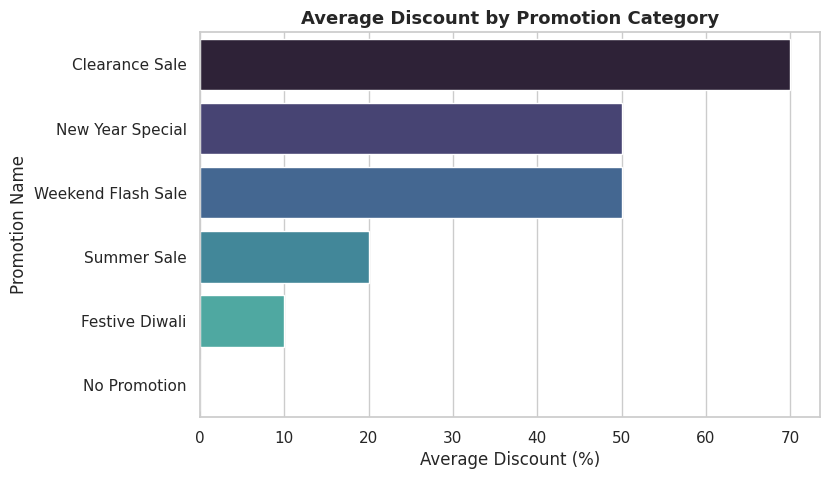

In [10]:
avg_discount = analysis.avg_discount_by_promotion(master)
visualization.plot_avg_discount(avg_discount)
avg_discount.round(1)


## Q6 — Total Number of Orders

In [11]:
orders = analysis.total_orders(master)
print(f"Total orders: {orders:,}")


Total orders: 3,510


## Q7 — Order-Level Detail, Filterable by Product / Date / Customer ID / Promotion

`analysis.filter_orders` is the Python equivalent of Power BI visual filters / slicers.


In [12]:
analysis.filter_orders(
    master,
    product_name="Apple iPhone 14",
    date_range=("2022-01-01", "2022-12-31"),
).head(10)


,Date,Customer Name,Product Name,UnitsSold,TotalSales,DiscountPct,DiscountValue,NetSales,Profit,Promotion Name,City
0,2022-05-20,Aman Verma,Apple iPhone 14,3,239997,0.20,"47,999.40","191,997.60","47,999.40",Summer Sale,Ahmedabad
1,2022-02-07,Rajat Saxena,Apple iPhone 14,3,239997,0.00,0.00,"239,997.00","59,999.25",No Promotion,Kanpur
2,2022-02-13,Kavya Mishra,Apple iPhone 14,2,159998,0.00,0.00,"159,998.00","39,999.50",No Promotion,Indore
3,2022-03-30,Jaya Kumar,Apple iPhone 14,3,239997,0.00,0.00,"239,997.00","59,999.25",No Promotion,Chennai
4,2022-11-09,Mohit Aggarwal,Apple iPhone 14,3,239997,0.00,0.00,"239,997.00","59,999.25",No Promotion,Patna
5,2022-06-28,Nikhil Khanna,Apple iPhone 14,2,159998,0.00,0.00,"159,998.00","39,999.50",No Promotion,Indore
6,2022-01-22,Aniket Sharma,Apple iPhone 14,1,79999,0.00,0.00,"79,999.00","19,999.75",No Promotion,Indore
7,2022-02-17,Neha Sinha,Apple iPhone 14,2,159998,0.00,0.00,"159,998.00","39,999.50",No Promotion,Kolkata
8,2022-06-04,Krishnan Menon,Apple iPhone 14,3,239997,0.00,0.00,"239,997.00","59,999.25",No Promotion,Chennai
9,2022-06-16,Lavanya Jain,Apple iPhone 14,3,239997,0.00,0.00,"239,997.00","59,999.25",No Promotion,Indore


## Q8 — Sales by City

/home/claude/project/notebooks/../src/visualization.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_city.values, y=sales_by_city.index, palette="rocket_r", ax=ax)


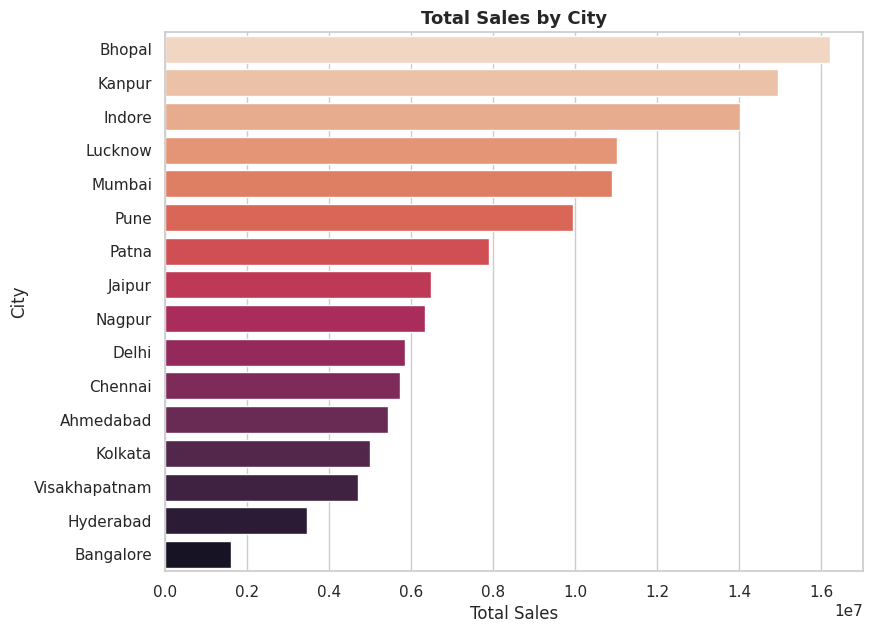

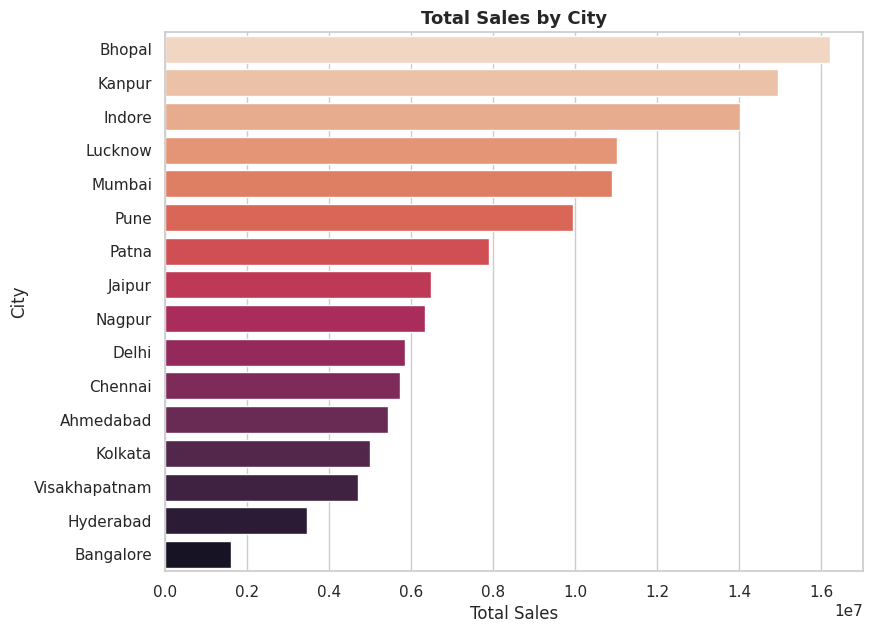

In [13]:
city_sales = analysis.sales_by_city(master)
visualization.plot_sales_by_city(city_sales)


## Export Cleaned Dataset (Optional)

In [14]:
import os
os.makedirs("../output", exist_ok=True)
master.to_csv("../output/master_sales_data.csv", index=False)
print("Saved: output/master_sales_data.csv")


Saved: output/master_sales_data.csv
